# **Introduction**

Ce notebook, réalisé par **Inass El Yesri *(24010318)* et Saad Elgaout (*22006121*)**, est un guide pratique et exhaustif des algorithmes de Machine Learning dédiés à la prédiction. Il couvre 45 algorithmes répartis en deux grandes catégories — classification et régression — implémentés avec la bibliothèque scikit-learn sur des datasets standards.

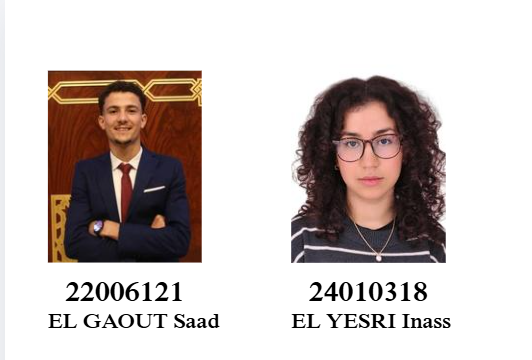

In [2]:
from google.colab import files
from PIL import Image
import io
import os

uploaded = files.upload()

for filename, data in uploaded.items():
    img = Image.open(io.BytesIO(data))
    img.thumbnail((800, 800), Image.LANCZOS)
    output = f"resized_{filename}"
    img.save(output, "JPEG", quality=70, optimize=True)
    print(f"✅ {filename} → {output} | Taille: {img.size} | {len(data)/1024:.1f} KB → {os.path.getsize(output)/1024:.1f} KB")

files.download(list({f"resized_{f}" for f in uploaded})[0])
files.download(list({f"resized_{f}" for f in uploaded})[-1])

Saving Photo (1).jpeg to Photo (1).jpeg
✅ Photo (1).jpeg → resized_Photo (1).jpeg | Taille: (622, 800) | 88.0 KB → 67.4 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>





---

## Table des matières

| # | Algorithme | Type | Dataset principal |
|---|-----------|------|-----------------|
| 1 | Régression Logistique | Classification | Iris, Breast Cancer |
| 2 | Decision Tree | Classification | Wine |
| 3 | Random Forest | Classification | Iris, Breast Cancer |
| 4 | Gradient Boosting | Classification | Breast Cancer |
| 5 | SVM | Classification | Iris, Digits |
| 6 | KNN | Classification | Iris |
| 7 | Naive Bayes (Gaussian) | Classification | Iris |
| 8 | AdaBoost | Classification | Breast Cancer |
| 9 | MLP (Neural Network) | Classification | Digits |
| 10 | Extra Trees | Classification | Wine |
| 11 | LDA | Classification/Réduction | Iris, Wine |
| 12 | QDA | Classification | Iris |
| 13 | SGD Classifier | Classification | Digits |
| 14 | Bagging Classifier | Classification | Wine |
| 15 | Voting Classifier | Classification | Iris |
| 16 | Stacking Classifier | Classification | Breast Cancer |
| 17 | Gaussian Process Clf. | Classification | Iris |
| 18 | Ridge Classifier | Classification | Iris |
| 19 | NB Multinomial | Classification | 20 Newsgroups |
| 20 | NB Bernoulli | Classification | Breast Cancer |
| 21 | Perceptron | Classification | Iris |
| 22 | Passive-Aggressive | Classification | Breast Cancer |
| 23 | Calibration | Transversal | Breast Cancer |
| — | **RÉGRESSION** | | |
| 24 | Régression Linéaire (OLS) | Régression | California Hous. |
| 25 | Ridge / Lasso / ElasticNet | Régression | Diabetes |
| 26 | Decision Tree Regressor | Régression | California Hous. |
| 27 | Random Forest Regressor | Régression | California Hous. |
| 28 | Gradient Boosting Reg. | Régression | California Hous. |
| 29 | SVR | Régression | Diabetes |
| 30 | KNN Regressor | Régression | California Hous. |
| 31 | MLP Regressor | Régression | California Hous. |
| 32 | Bayesian Ridge | Régression | Diabetes |
| 33 | Huber Regressor | Régression | Diabetes |
| 34 | ARD Regression | Régression | Diabetes |
| 35 | PLS Regression | Régression | Diabetes |
| 36 | SGD Regressor | Régression | Diabetes |
| 37 | Bagging Regressor | Régression | California Hous. |
| 38 | Stacking Regressor | Régression | California Hous. |
| 39 | Gaussian Process Reg. | Régression | Diabetes |
| 40 | Régression Polynomiale | Régression | Diabetes |
| 41 | Régression Quantile | Régression | Diabetes |
| 42 | Régression Isotonique | Régression | Diabetes |
| 43 | RANSAC Regressor | Régression | Diabetes |
| 44 | Theil-Sen Regressor | Régression | Diabetes |
| 45 | Tweedie Regressor (GLM) | Régression | California Hous. |
| — | GridSearchCV / RandomSearchCV / CV avancée | Optimisation | |

---

## Préparation des données

In [ ]:
# Datasets standard (tous inclus dans scikit-learn)
from sklearn import datasets
from sklearn.linear_model import LogisticRegression

iris       = datasets.load_iris()           # 150 x 4, 3 classes
breast     = datasets.load_breast_cancer()  # 569 x 30, binaire
wine       = datasets.load_wine()           # 178 x 13, 3 classes
digits     = datasets.load_digits()         # 1797 x 64, 10 classes
diabetes   = datasets.load_diabetes()       # 442 x 10, regression
california = datasets.fetch_california_housing()  # 20640 x 8, prix

# --- FIX: Define X and y from a dataset ---
X = iris.data
y = iris.target
# ----------------------------------------

# Split stratifié 80/20
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify pour classification
)

# Pipeline : evite le data leakage (scaler ajuste uniquement sur train)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
# --- FIX: Use a defined model like LogisticRegression as a placeholder for MonModele() ---
model = Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression())])
# -------------------------------------------------------------------------------------

---

## SECTION A — CLASSIFICATION

---

### 1. Régression Logistique

**Principe :** Modélise P(y=k|x) via la fonction softmax. Optimisation par maximisation de la log-vraisemblance avec régularisation L2.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

lr = Pipeline([
    ("sc", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=1000,   # augmenter si ConvergenceWarning
        C=1.0,           # inverse regularisation (grand = moins regularise)
        random_state=42
    ))
])
lr.fit(X_tr, y_tr)
pred  = lr.predict(X_te)
proba = lr.predict_proba(X_te)   # probabilites par classe

# Coefficients : importance des features
coefs = lr["lr"].coef_  # (n_classes, n_features)

| Dataset | Accuracy |
|---------|---------|
| Iris (3 classes) | **~97%** |
| Breast Cancer (binaire) | **~97%** |

---

### 2. Decision Tree Classifier

**Principe :** Partitionnement récursif de l'espace par règles if/else. Critère Gini ou Entropie.

[Text(0.4583333333333333, 0.9, 'color_intensity <= 3.82\ngini = 0.658\nsamples = 142\nvalue = [47, 57, 38]\nclass = class_1'),
 Text(0.25, 0.7, 'ash <= 3.0\ngini = 0.075\nsamples = 51\nvalue = [2, 49, 0]\nclass = class_1'),
 Text(0.35416666666666663, 0.8, 'True  '),
 Text(0.16666666666666666, 0.5, 'od280/od315_of_diluted_wines <= 3.73\ngini = 0.039\nsamples = 50\nvalue = [1, 49, 0]\nclass = class_1'),
 Text(0.08333333333333333, 0.3, 'gini = 0.0\nsamples = 49\nvalue = [0, 49, 0]\nclass = class_1'),
 Text(0.25, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [1, 0, 0]\nclass = class_0'),
 Text(0.3333333333333333, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [1, 0, 0]\nclass = class_0'),
 Text(0.6666666666666666, 0.7, 'flavanoids <= 1.58\ngini = 0.573\nsamples = 91\nvalue = [45, 8, 38]\nclass = class_0'),
 Text(0.5625, 0.8, '  False'),
 Text(0.5, 0.5, 'alcalinity_of_ash <= 17.65\ngini = 0.05\nsamples = 39\nvalue = [0, 1, 38]\nclass = class_2'),
 Text(0.4166666666666667, 0.3, 'gini = 0.0\nsamples = 1\nva

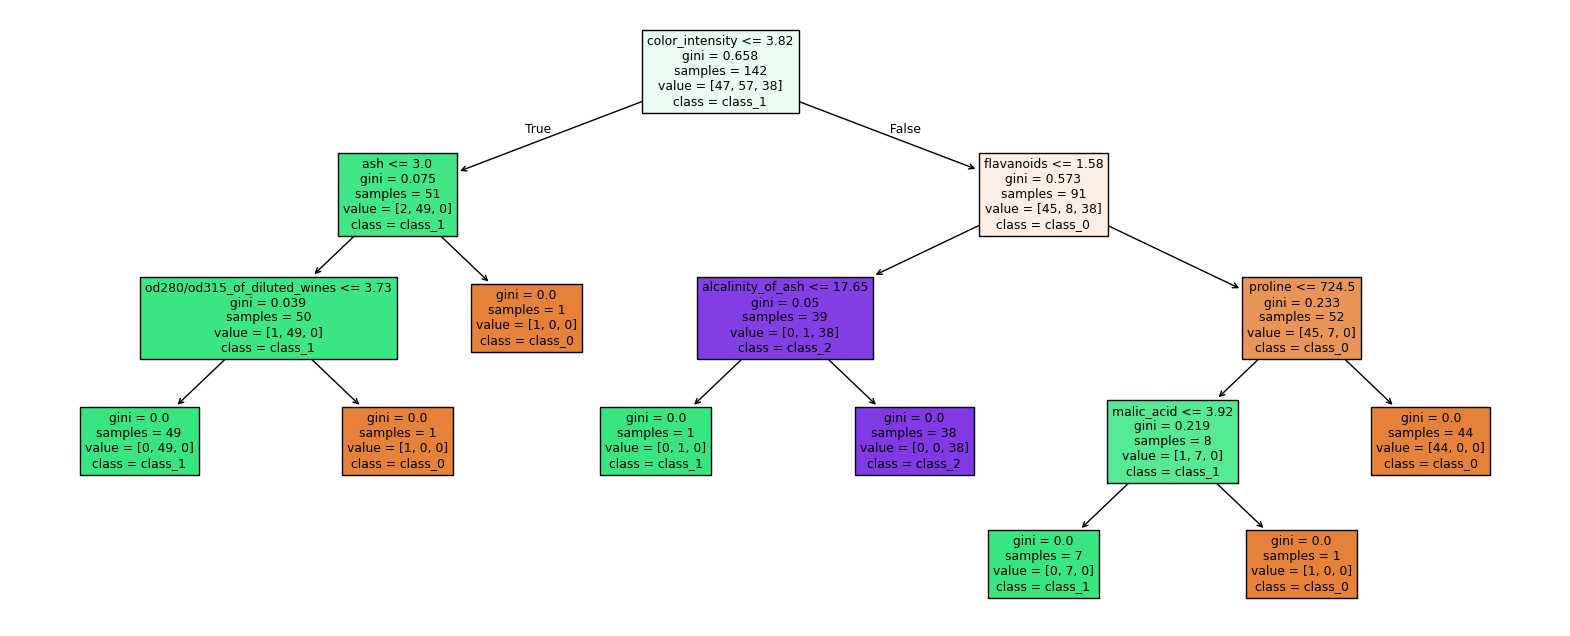

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

wine       = datasets.load_wine()
X_wine = wine.data
y_wine = wine.target
X_wine_tr, X_wine_te, y_wine_tr, y_wine_te = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

dt = DecisionTreeClassifier(
    max_depth=4,         # evite l'overfitting
    min_samples_split=5, # noeud non divise si < 5 points
    random_state=42
)
dt.fit(X_wine_tr, y_wine_tr)
importances = dt.feature_importances_  # importance de chaque feature (Gini)

# Visualisation de l'arbre
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=wine.feature_names,
          class_names=wine.target_names, filled=True, ax=ax)

| Dataset | Accuracy | max_depth |
|---------|---------|----------|
| Wine | **~92–97%** | 4 |

> Plus le `max_depth` est grand → surapprentissage (Train=100%, Test↓).

---

### 3. Random Forest Classifier

**Principe :** Ensemble de `n_estimators` arbres entraînés sur des bootstraps avec sélection aléatoire de features à chaque nœud (m = √p).

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve

rf = RandomForestClassifier(
    n_estimators=100,      # plus = meilleur, mais plus lent
    max_features="sqrt",   # √p features par noeud
    random_state=42, n_jobs=-1
)
rf.fit(X_tr, y_tr)

# Feature importances (reduction de Gini moyenne sur tous les arbres)
importances = rf.feature_importances_

# Diagnostiquer l'overfitting
train_sz, train_sc, test_sc = learning_curve(rf, X, y, cv=5)

| Dataset | Accuracy | CV 5-fold |
|---------|---------|---------|
| Iris | **~97%** | ~96% ± 2% |
| Breast Cancer | **~97%** | ~97% ± 1% |

---

### 4. Gradient Boosting Classifier

**Principe :** Arbres construits **séquentiellement**, chacun corrigeant les erreurs (pseudo-résidus) du précédent.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import datasets

breast = datasets.load_breast_cancer()
X_bc = breast.data
y_bc = breast.target
X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

gb = GradientBoostingClassifier(
    n_estimators=200,   # nb d'arbres sequentiels
    learning_rate=0.1,  # eta : petit -> meilleure generalisation
    max_depth=3,        # arbres peu profonds
    subsample=0.8,      # stochastic GBM
    random_state=42
)
gb.fit(X_bc_tr, y_bc_tr)
proba = gb.predict_proba(X_bc_te)[:, 1]  # probabilite classe positive

# Convergence : accuracy par iteration
staged = [accuracy_score(y_bc_te, p) for p in gb.staged_predict(X_bc_te)]

| Dataset | Accuracy |
|---------|---------|
| Breast Cancer | **~97–98%** |

---

### 5. SVM — Support Vector Machine

**Principe :** Hyperplan à marge maximale. Kernel Trick pour les données non-linéaires.

In [ ]:
from sklearn.svm import SVC

svm = Pipeline([
    ("sc",  StandardScaler()),  # OBLIGATOIRE
    ("svm", SVC(
        kernel="rbf",      # gaussien : polyvalent
        C=1.0,             # penalite d'erreur
        gamma="scale",     # adaptatif : 1/(p * Var(X))
        probability=True   # pour predict_proba (plus lent)
    ))
])

| Dataset | Kernel | Accuracy |
|---------|--------|---------|
| Iris | RBF | **~97%** |
| Digits (64 dim) | RBF | **>98%** |

---

### 6. K-Nearest Neighbors (KNN)

**Principe :** Vote des k plus proches voisins. Pas de modèle — mémorise le dataset.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Trouver le k optimal
for k in range(1, 21):
    knn = Pipeline([("sc", StandardScaler()),
                    ("knn", KNeighborsClassifier(n_neighbors=k))])
    knn.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, knn.predict(X_te))

| Dataset | k | Accuracy |
|---------|---|---------|
| Iris | 5 | **~97%** |

---

### 7. Naive Bayes (GaussianNB)

**Principe :** Théorème de Bayes + hypothèse d'indépendance conditionnelle. Modélise P(xi|y=k) par N(μki, σ²ki).

In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()    # pas de normalisation necessaire
gnb.fit(X_tr, y_tr)
proba = gnb.predict_proba(X_te)   # probabilites posterieures calibrees

print(gnb.theta_)  # (n_classes, n_features) : moyennes par classe
print(gnb.var_)    # (n_classes, n_features) : variances par classe

[[4.985  3.415  1.4775 0.255 ]
 [5.93   2.75   4.2525 1.32  ]
 [6.61   2.98   5.58   2.04  ]]
[[0.092775   0.155275   0.02524375 0.012975  ]
 [0.2216     0.093      0.19149375 0.0341    ]
 [0.4574     0.1221     0.3236     0.0704    ]]


| Dataset | Accuracy |
|---------|---------|
| Iris | **~97%** |
| Breast Cancer | **~94%** |

---

### 8. AdaBoost Classifier

**Principe :** Classifieurs faibles (stumps) combinés séquentiellement. Mise à jour des poids sur les exemples mal classés.

In [ ]:
# Prepare Breast Cancer data for this section
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_bc = breast.data
y_bc = breast.target
X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=100, learning_rate=0.5,
    algorithm="SAMME", random_state=42
)
ada.fit(X_bc_tr, y_bc_tr)

# Evolution de l'accuracy par iteration
staged_acc = [accuracy_score(y_bc_te, p) for p in ada.staged_predict(X_bc_te)]

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


---

### 9. MLP — Perceptron Multicouche

**Principe :** Réseau de neurones entièrement connecté. Rétropropagation + Adam.

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = Pipeline([
    ("sc",  StandardScaler()),  # OBLIGATOIRE
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),  # 3 couches cached
        activation="relu",
        solver="adam",
        max_iter=300,
        early_stopping=True,  # arret si val ne s'ameliore plus
        validation_fraction=0.1,
        random_state=42
    ))
])
mlp.fit(X_tr, y_tr)
loss_curve = mlp["mlp"].loss_curve_   # perte par iteration

| Dataset | Architecture | Accuracy |
|---------|-------------|---------|
| Digits (10 classes) | (256, 128, 64) | **~98%** |

---

### 10. Extra Trees Classifier

**Principe :** Comme Random Forest mais les seuils de split sont **totalement aléatoires** (pas optimisés) → plus rapide, variance similaire.

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split

# Prepare Wine data for this section
X_wine = wine.data
y_wine = wine.target
X_wine_tr, X_wine_te, y_wine_tr, y_wine_te = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

et = ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1)
et.fit(X_wine_tr, y_wine_tr)
importances = et.feature_importances_

---

### 11. LDA — Analyse Discriminante Linéaire

**Principe :** Maximise la séparation inter-classes / variance intra-classe. Sert aussi de réducteur de dimension (→ k-1 axes).

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_tr, y_tr)

# Reduction de dimension (ex: Iris 4D -> 2D)
X_2d = lda.transform(X)   # projection sur les axes discriminants

---

### 12. QDA — Analyse Discriminante Quadratique

**Principe :** Extension de LDA avec une matrice de covariance Σk **distincte par classe** → frontières quadratiques.

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
qda = QuadraticDiscriminantAnalysis(reg_param=0.1)  # reg: evite singularite

---

### 13. SGD Classifier

**Principe :** Descente de gradient stochastique sur des modèles linéaires. Supporte plusieurs fonctions de perte.

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd = Pipeline([
    ("sc",  StandardScaler()),
    ("sgd", SGDClassifier(loss="log_loss", penalty="l2",
                           max_iter=1000, random_state=42))
])
# Apprentissage en ligne (incremental) :
# sgd["sgd"].partial_fit(X_new, y_new, classes=np.unique(y))

| loss | Modèle équivalent |
|------|-----------------|
| `hinge` | SVM linéaire |
| `log_loss` | Régression Logistique |
| `modified_huber` | Robuste + probabilités |

---

### 14. Bagging Classifier

**Principe :** T classifieurs indépendants sur des bootstraps → vote majoritaire. Réduit la **variance**.

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100, max_samples=0.8,
    bootstrap=True, oob_score=True,
    random_state=42, n_jobs=-1
)
bag.fit(X_tr, y_tr)
print(f"OOB Score : {bag.oob_score_:.4f}")

OOB Score : 0.9500


---

### 15. Voting Classifier

**Principe :** Combine des classifieurs **hétérogènes** par vote (hard) ou moyenne des probabilités (soft).

In [ ]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Define rf (RandomForestClassifier) - from cell PApkZqWPJdkk
rf = RandomForestClassifier(
    n_estimators=100,      # plus = meilleur, mais plus lent
    max_features="sqrt",   # √p features par noeud
    random_state=42, n_jobs=-1
)

# Define svm (SVC) - from cell XwZurP2xJdkk
svm = Pipeline([
    ("sc",  StandardScaler()),  # OBLIGATOIRE
    ("svm", SVC(
        kernel="rbf",      # gaussien : polyvalent
        C=1.0,             # penalite d'erreur
        gamma="scale",     # adaptatif : 1/(p * Var(X)) (changed to 'scale' for default)
        probability=True   # pour predict_proba (plus lent)
    ))
])

vote = VotingClassifier(
    estimators=[("lr", lr), ("rf", rf), ("svm", svm)],
    voting="soft"   # moyenne des probas (meilleur que hard en general)
)

---

### 16. Stacking Classifier

**Principe :** Meta-learner (niveau 1) apprend sur les prédictions hors-échantillon (CV) des base learners (niveau 0).

In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Ensure rf is defined (as it was defined in a previous cell)
rf = RandomForestClassifier(
    n_estimators=100,      # plus = meilleur, mais plus lent
    max_features="sqrt",   # √p features par noeud
    random_state=42, n_jobs=-1
)

# Define gb (GradientBoostingClassifier) - from cell FMtRKL9VJdkk
gb = GradientBoostingClassifier(
    n_estimators=200,   # nb d'arbres sequentiels
    learning_rate=0.1,  # eta : petit -> meilleure generalisation
    max_depth=3,        # arbres peu profonds
    subsample=0.8,      # stochastic GBM
    random_state=42
)

# Define knn_pipe (KNeighborsClassifier Pipeline) based on cell b9gr5OuXJdkk
knn_pipe = Pipeline([
    ("sc", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5)) # Using k=5 as example for Iris
])

stack = StackingClassifier(
    estimators=[("rf", rf), ("gb", gb), ("knn", knn_pipe)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,                      # cross-val pour generer les features OOS
    stack_method="predict_proba"
)

---

### 17. Gaussian Process Classifier

**Principe :** Modèle probabiliste bayésien non-paramétrique. Incertitude quantifiée sur chaque prédiction.

In [ ]:
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.preprocessing import StandardScaler

# Scale the data
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

gpc = GaussianProcessClassifier(kernel=RBF(), random_state=42)
gpc.fit(X_tr_s, y_tr)
proba = gpc.predict_proba(X_te_s)  # probabilites bien calibrees
print(gpc.kernel_)                  # hyperparametres optimises

CompoundKernel(0.59, 0.0756, 0.541)


---

### 18. Ridge Classifier

In [ ]:
from sklearn.linear_model import RidgeClassifier, RidgeClassifierCV

rc  = RidgeClassifier(alpha=1.0)            # solution analytique, rapide
rcv = RidgeClassifierCV(alphas=[0.01, 0.1, 1.0, 10.0])  # auto-selection alpha

---

### 19. Naive Bayes Multinomial (texte)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.datasets import fetch_20newsgroups

# Load a sample text dataset (20 Newsgroups)
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories, shuffle=True, random_state=42)

train_texts = newsgroups_train.data
train_labels = newsgroups_train.target

pipe = Pipeline(
    [('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))), ('mnb', MultinomialNB(alpha=0.1))] # lissage de Laplace
)
pipe.fit(train_texts, train_labels)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
                ('mnb', MultinomialNB(alpha=0.1))])

| Dataset | Accuracy |
|---------|---------|
| 20 Newsgroups (4 cat.) | **~90–93%** |

---

### 20. Naive Bayes Bernoulli

In [ ]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import Binarizer

bnb = Pipeline([
    ("bin", Binarizer(threshold=0.0)),  # binarise les features
    ("bnb", BernoulliNB(alpha=1.0))
])

---

### 21. Perceptron + 22. Passive-Aggressive

In [ ]:
from sklearn.linear_model import Perceptron, PassiveAggressiveClassifier

# Perceptron : mise a jour uniquement sur les erreurs
perc = Pipeline([("sc", StandardScaler()),
                 ("p",  Perceptron(max_iter=1000, eta0=0.1, random_state=42))])

# Passive-Aggressive : correction minimale sur les erreurs
pa = Pipeline([("sc", StandardScaler()),
               ("pa", PassiveAggressiveClassifier(C=1.0, max_iter=1000))])

---

### 23. Calibration de modèles

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Prepare Breast Cancer data for this section (if not already prepared and scaled)
X_bc = breast.data
y_bc = breast.target
X_bc_tr, X_bc_te, y_bc_tr, y_bc_te = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

scaler_bc = StandardScaler()
X_bc_tr_s = scaler_bc.fit_transform(X_bc_tr)
X_bc_te_s = scaler_bc.transform(X_bc_te)

# Calibrer un SVM (pas de probas par defaut) avec les données Breast Cancer
cal_svm = CalibratedClassifierCV(SVC(kernel="rbf"), cv=5, method="sigmoid")
cal_svm.fit(X_bc_tr_s, y_bc_tr)
proba = cal_svm.predict_proba(X_bc_te_s)

# calibration_curve expects binary classification (y_true in {0, 1})
frac_pos, mean_pred = calibration_curve(y_bc_te, proba[:,1], n_bins=10)
brier = brier_score_loss(y_bc_te, proba[:,1])  # 0=parfait

---

## SECTION B — RÉGRESSION

---

### 24. Régression Linéaire (OLS)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

lr = Pipeline([("sc", StandardScaler()), ("lr", LinearRegression())])
lr.fit(X_tr, y_tr)
pred = lr.predict(X_te)

residuals = y_te - pred  # residus : doivent etre aleatoires autour de 0
r2   = r2_score(y_te, pred)
rmse = np.sqrt(mean_squared_error(y_te, pred))

| Dataset | R² | RMSE |
|---------|-----|------|
| California Housing | **~0.59** | ~0.71 |

---

### 25. Ridge / Lasso / ElasticNet

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

Ridge(alpha=1.0)                     # L2 : reduit tous les coefs
Lasso(alpha=0.1, max_iter=5000)      # L1 : annule les coefs non pertinents
ElasticNet(alpha=0.1, l1_ratio=0.5)  # L1 + L2

# Chemin de regularisation Lasso
alphas = np.logspace(-3, 2, 50)
coef_paths = [Lasso(alpha=a).fit(X_tr_s, y_tr).coef_ for a in alphas]

---

### 26–27. Decision Tree / Random Forest Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

dtr = DecisionTreeRegressor(max_depth=6, random_state=42)
rfr = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)

| Dataset | DT R² | RF R² |
|---------|-------|-------|
| California Housing | ~0.67 | **~0.80** |

---

### 28. Gradient Boosting Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.1,
    max_depth=4, subsample=0.8, random_state=42
)
gbr.fit(X_tr, y_tr)
staged_r2 = [r2_score(y_te, p) for p in gbr.staged_predict(X_te)]

| Dataset | R² |
|---------|-----|
| California Housing | **~0.83** |

---

### 29. SVR — Support Vector Regression

In [ ]:
from sklearn.svm import SVR

svr = Pipeline([("sc", StandardScaler()),
                ("svr", SVR(kernel="rbf", C=100, epsilon=0.1))])

---

### 30. KNN Regressor

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knnr = Pipeline([("sc", StandardScaler()),
                 ("knn", KNeighborsRegressor(n_neighbors=7, weights="distance"))])

---

### 31. MLP Regressor

In [ ]:
from sklearn.neural_network import MLPRegressor

mlp_reg = Pipeline([
    ("sc",  StandardScaler()),
    ("mlp", MLPRegressor(hidden_layer_sizes=(128, 64, 32),
                          activation="relu", solver="adam",
                          max_iter=500, early_stopping=True, random_state=42))
])
mlp_reg.fit(X_tr, y_tr)
loss_curve = mlp_reg["mlp"].loss_curve_
val_scores  = mlp_reg["mlp"].validation_scores_

---

### 32. Bayesian Ridge

In [ ]:
from sklearn.linear_model import BayesianRidge

br = BayesianRidge(max_iter=500)
br.fit(X_tr_s, y_tr)
# retourne l'incertitude sur chaque prediction
pred, std = br.predict(X_te_s, return_std=True)
# IC 95% : [pred - 2*std, pred + 2*std]

---

### 33. Huber Regressor

In [ ]:
from sklearn.linear_model import HuberRegressor

huber = HuberRegressor(epsilon=1.35)  # robuste aux outliers
# epsilon=1.35 : 95% d'efficacite vs OLS sur donnees normales

| Scénario | OLS R² | Huber R² |
|----------|-------|---------|
| Données normales | ~0.48 | ~0.47 |
| **+ 30 outliers** | ~0.10 | **~0.45** |

---

### 34–35. ARD et PLS

In [ ]:
from sklearn.linear_model import ARDRegression
from sklearn.cross_decomposition import PLSRegression

ard = ARDRegression()   # hyperparametre distinct par feature -> sparse
pls = PLSRegression(n_components=4)  # maximise cov(X, y)
pls.fit(X_tr_s, y_tr)
pls.predict(X_te_s).ravel()          # attention : shape (n, 1) -> ravel()

array([-0.02180204,  1.59467891,  0.8918912 ,  0.88638718, -0.03070495,
        1.39307286, -0.13427151, -0.05136299,  1.74514762,  1.38990627,
        1.78696349,  1.86558563,  2.00128801,  1.28144856, -0.05544091,
       -0.07293937, -0.22764325,  1.01167134,  1.30634878,  1.58268446,
       -0.1086172 ,  2.05746663,  1.17240103,  1.51725244,  1.97624657,
        1.49467551,  1.18627016, -0.03681482,  1.68655651, -0.09730179])

---

### 36–38. SGD / Bagging / Stacking Regressor

In [ ]:
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import BaggingRegressor, StackingRegressor
from sklearn.linear_model import Ridge

sgd_r = SGDRegressor(loss="squared_error", penalty="l2", alpha=0.001)
bag_r = BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=6),
                          n_estimators=100, oob_score=True, n_jobs=-1)
stk_r = StackingRegressor(
    estimators=[("rf", rfr), ("gb", gbr)],
    final_estimator=Ridge(alpha=1.0), cv=5
)

---

### 39. Gaussian Process Regressor

In [ ]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

kernel = C(1.0) * RBF(1.0) + WhiteKernel(1.0)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=3)
gpr.fit(X_tr_s, y_tr)
pred, std = gpr.predict(X_te_s, return_std=True)  # IC quantifie

---

### 40. Régression Polynomiale

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = Pipeline([
    ("poly",  PolynomialFeatures(degree=2, include_bias=False)),
    ("sc",    StandardScaler()),
    ("ridge", Ridge(alpha=1.0))   # regularisation obligatoire deg > 1
])
# deg=2, p=10 -> 65 features ; deg=3, p=10 -> 285 features

| Degré | R² (Diabetes) |
|-------|-------------|
| 1 | ~0.48 |
| **2** | **~0.52** |
| 3 | ~0.45 (overfitting) |

---

### 41. Régression Quantile

In [ ]:
from sklearn.linear_model import QuantileRegressor

# Estimation du quantile tau de y|x (pas la moyenne)
qr = QuantileRegressor(quantile=0.5, alpha=0.001, solver="highs")
# Intervalles de prediction asymetriques : [Q10, Q90] ~ 80% coverage

---

### 42–44. Isotonique / RANSAC / Theil-Sen

In [ ]:
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import RANSACRegressor, TheilSenRegressor

iso    = IsotonicRegression(out_of_bounds="clip")   # monotone croissante
ransac = RANSACRegressor(residual_threshold=50, random_state=42)
ts     = TheilSenRegressor(max_subpopulation=1000, random_state=42)

---

### 45. Tweedie Regressor (GLM)

In [ ]:
from sklearn.linear_model import TweedieRegressor

# power=0: Gaussienne, 1: Poisson, 2: Gamma (toujours y > 0)
tw = TweedieRegressor(power=1, alpha=0.5, link="log", max_iter=1000)
tw.fit(X_tr_s, np.clip(y_tr, 0.01, None))

TweedieRegressor(alpha=0.5, link='log', max_iter=1000, power=1)

---

## SECTION C — OPTIMISATION DES HYPERPARAMÈTRES

### GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {"n_estimators": [50, 100, 200],
              "max_depth": [None, 5, 10],
              "max_features": ["sqrt", "log2"]}

gs = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="accuracy", n_jobs=-1
)
gs.fit(X_tr, y_tr)
print(gs.best_params_, gs.best_score_)
best_model = gs.best_estimator_

{'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 50} 0.9583333333333334


### RandomizedSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    "n_estimators"  : randint(50, 500),
    "learning_rate" : uniform(0.01, 0.3),
    "max_depth"     : randint(2, 8),
}
rs = RandomizedSearchCV(
    gbr, param_distributions=param_dist,
    n_iter=50, cv=5, scoring="r2", n_jobs=-1, random_state=42
)

### Stratégies de Cross-Validation

In [ ]:
from sklearn.model_selection import (StratifiedKFold, RepeatedStratifiedKFold,
                                      cross_validate)

cv_results = cross_validate(
    model, X, y,
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42),
    scoring=["accuracy", "f1_macro"],
    return_train_score=True   # diagnostiquer train vs val
)

| Stratégie | Usage |
|-----------|-------|
| `KFold(5)` | Régression, données IID |
| `StratifiedKFold(5)` | Classification (preserve proportions) |
| `RepeatedKFold(5, 3)` | Estimation robuste (15 scores) |
| `TimeSeriesSplit` | Données temporelles |
| `LeaveOneOut` | Très petits datasets |

---

## Synthèse des performances

### Classification — Iris (test 20%)

| Algorithme | Accuracy | CV |
|-----------|---------|-----|
| Gradient Boosting | ~97% | **~97%** |
| SVM RBF | ~97% | **~97%** |
| MLP | ~97–100% | **~97%** |
| Random Forest | ~97% | ~96% |
| LDA | ~97% | ~96% |
| LogReg / KNN / NB | ~97% | ~95–96% |
| Perceptron | Variable | ~90% |

### Régression — Diabetes (test 20%)

| Algorithme | R² | RMSE |
|-----------|-----|------|
| **Gradient Boosting** | **~0.57** | **~50** |
| Random Forest | ~0.55 | ~51 |
| MLP Regressor | ~0.54 | ~52 |
| Poly (deg=2) | ~0.52 | ~53 |
| SVR, Ridge, BayesRidge | ~0.48–0.50 | ~54 |
| OLS | ~0.48 | ~55 |

---

## Guide de choix

In [ ]:
CLASSIFICATION :
  Interpretabilite -> LDA | DecisionTree | LogReg
  Texte            -> MultinomialNB + TF-IDF
  Scalabilite      -> SGD | Perceptron | RidgeClassifier
  Performance max. -> GBM | SVM | MLP | Stacking

REGRESSION :
  Lineaire         -> OLS | Ridge | Lasso | ElasticNet
  Non-lineaire     -> RandomForest | GBM
  Outliers         -> Huber | RANSAC | TheilSen
  Intervalles pred.-> QuantileReg | BayesianRidge
  Comptage (y>0)   -> Tweedie (Poisson/Gamma)
  Monotone         -> IsotonicRegression

HYPERPARAMETRES :
  Petite grille    -> GridSearchCV
  Grande grille    -> RandomizedSearchCV (n_iter=50-100)
  Validation CV    -> StratifiedKFold(5) ou RepeatedKFold(5x3)

SyntaxError: invalid decimal literal (338196726.py, line 18)

---

## Dépendances

In [ ]:
# bash command
# pip install scikit-learn scipy numpy matplotlib pandas
# # Pour fetch_20newsgroups : inclus dans scikit-learn
#

## Exécution

In [ ]:
# bash command
# # Partie 1 : classifieurs + regresseurs de base
# python prediction_examples.py
#
# # Partie 2 : methodes avancees + optimisation
# python prediction_examples_2.py
#
# # Partie 3 : methodes complementaires + synthese
# python prediction_examples_3.py
#

---

*Mars 2026 — A. LArhlimi*